Inameti Mercy Etim

In [1]:
# Importing Iris dataset from sklearn.datasets
from sklearn.datasets import load_iris

In [2]:
# Load the datset and store it in a variable called "iris"
iris = load_iris()

In [3]:
# printing feature and target names from iris dataset
print(iris.feature_names)

print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [4]:
# Importing pandas to read dataframe
import pandas as pd

In [5]:
# Convert iris to dataframe and store the dataframe in a variable called 'df'
df = pd.DataFrame(iris.data, columns = iris.feature_names)
df['species'] = iris.target
print(df.head(3))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   

   species  
0        0  
1        0  
2        0  


In [6]:
# Check for shape of dataset(no of rows and columns)
df.shape

(150, 5)

In [7]:
# Check for information on dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [8]:
# Check for correlation
correlation = df.corr()['species'].sort_values(ascending = False)
print(correlation)

species              1.000000
petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)    -0.426658
Name: species, dtype: float64


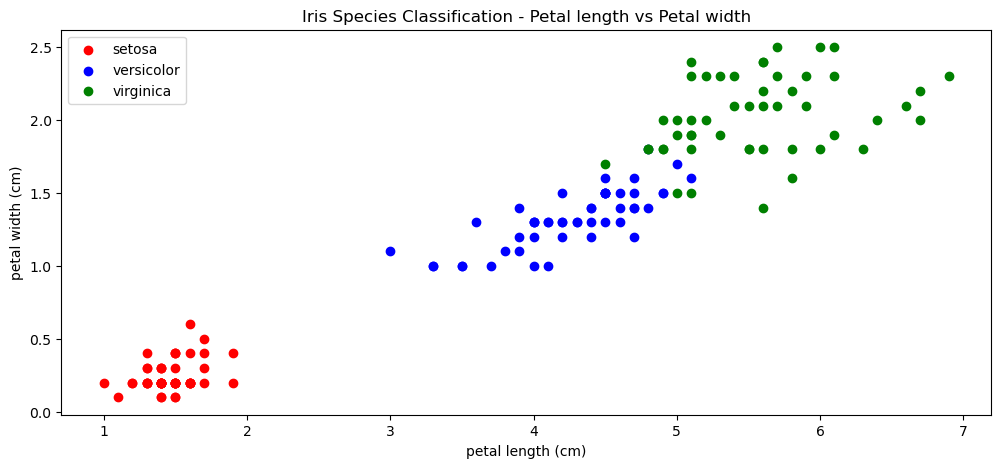

In [9]:
# Importing matplotlib for visualization
import matplotlib.pyplot as plt

plt.figure(figsize = (12,5))

colors = ['red','blue','green']

for i in range(3):
    plt.scatter(
        df[df["species"] == i] ['petal length (cm)'],
        df[df["species"] == i] ['petal width (cm)'],
        color = colors[i],
        label = iris.target_names[i]
    )
    
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Iris Species Classification - Petal length vs Petal width')
plt.legend()
plt.show()      

## Visualization Insight — Scatter Plot Analysis

The scatter plot showed a very distinct separation of each class from the others. Each class is tightly grouped together, surrounded by members of the same class, meaning each class has very distinct properties.

I used three colors to identify each class:
- Red = Setosa
- Blue = Versicolor  
- Green = Virginica

The clear separation between clusters tells us that the model will be able to learn and classify each flower type accurately.

This is why I chose K-Nearest Neighbors (KNN) as my algorithm. If the closest data points to any given point on the scatter plot are of the same color, they belong to the same class. KNN leverages this proximity principle — identifying which class a new data point belongs to based on the class of its nearest neighbors.

In [10]:
# Scaling my data
from sklearn.preprocessing import StandardScaler

SCA = StandardScaler()
df_scaled = SCA.fit_transform(df.drop(columns = ["species"])) # scale only features, target is a label not a measurement

In [11]:
# Splitting the dataset
from sklearn.model_selection import train_test_split

x = df_scaled
y = df["species"]

x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [12]:
print(x_train.shape)
print(x_test.shape)

(120, 4)
(30, 4)


In [13]:
# Model Building 
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors = 5)

# fit the model
model.fit(x_train,y_train)

# use the model to predict 
y_pred = model.predict(x_test)

In [14]:
# Evaluating the model

# Classification Report
from sklearn.metrics import classification_report

cr = classification_report(y_test,y_pred,target_names = iris.target_names)
print('Classification report:\n',cr)

Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



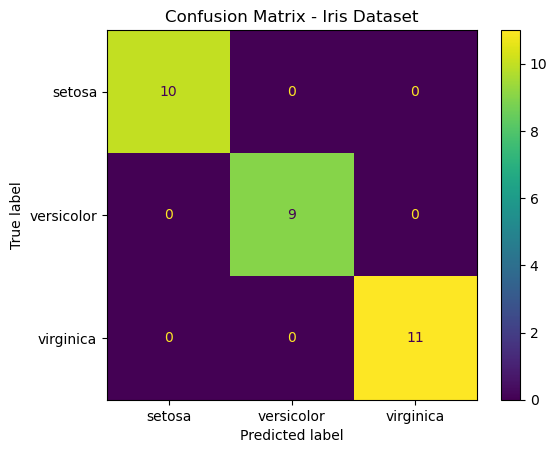

In [15]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = iris.target_names)
disp.plot()
plt.title("Confusion Matrix - Iris Dataset")
plt.show()

## Model Evaluation — Final Insight

The KNN Classifier (K=5) was trained on 120 samples and tested on 30 samples from the Iris dataset.

Results from the Classification Report:

- Accuracy: 1.0
- Precision: 1.0
- Recall: 1.0
- F1 Score: 1.0

The Confusion Matrix confirmed that the model classified all 30 test samples correctly with zero misclassifications.

This perfect accuracy is consistent with our scatter plot analysis which showed that the three flower classes are very distinctly separated. KNN was the ideal algorithm because each data point is surrounded by neighbors of the same class, making classification straightforward.

Final Accuracy: 100%